# Parkinson's Disease Gene Expression Analysis
## Notebook 2: Preprocessing and Exploratory Data Analysis 

Dataset: GSE99039 (GEO)

Flow of the notebook:
- Load the expression data
- Transpose expression matrix for ML format
- Load phenotype labels
- Check class balance
- Gene variance analysis
- Save the labeled dataset

Author: Athanasiadou Maria

In [1]:
# Import basic libraries for data analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Step 1: Load the expression data

In [2]:
# Load dataset saved from Notebook 01
data = pd.read_csv("../data/raw_expression.csv.gz", index_col=0, compression="gzip")
print(f"Expression matrix shape: {data.shape}")
data.head(5)

Expression matrix shape: (54675, 558)


,GSM2630758,GSM2630759,GSM2630760,GSM2630761,GSM2630762,GSM2630763,GSM2630764,GSM2630765,GSM2630766,GSM2630767,...,GSM2631306,GSM2631307,GSM2631308,GSM2631309,GSM2631310,GSM2631311,GSM2631312,GSM2631313,GSM2631314,GSM2631315
ID_REF,,,,,,,,,,,,,,,,,,,,,
1007_s_at,5.397,4.952,5.331,5.601,5.087,5.921,5.153,5.341,5.261,5.147,...,5.583,5.535,5.737,4.937,5.765,6.056,5.989,5.697,5.567,5.529
1053_at,5.199,5.198,4.970,5.816,5.443,5.430,5.243,5.167,5.324,5.489,...,5.775,5.004,5.672,5.415,5.195,5.282,5.228,5.528,5.706,5.078
117_at,8.327,8.589,8.629,9.628,9.449,9.230,9.269,9.095,9.184,8.623,...,8.426,7.061,6.771,8.691,7.073,7.325,8.567,6.844,8.511,8.458
121_at,7.042,6.935,7.701,6.909,7.284,7.153,6.850,7.541,6.918,6.714,...,7.192,7.326,7.319,6.702,7.747,7.712,7.743,7.468,7.526,7.673
1255_g_at,2.463,2.388,2.349,2.268,2.407,2.137,2.029,2.464,2.607,2.286,...,2.178,2.300,2.302,2.559,2.513,2.437,2.530,2.506,2.708,2.810


## Step 2: Transpose for ML format
ML format requires samples as rows and genes as columns. 

In [3]:
# Transpose expression matrix
t_data = data.T
print (f"Transposed expression matrix shape: {t_data.shape}")
t_data.head(5)

Transposed expression matrix shape: (558, 54675)


ID_REF,1007_s_at,1053_at,117_at,121_at,1255_g_at,1294_at,1316_at,1320_at,1405_i_at,1431_at,...,AFFX-r2-Ec-bioD-3_at,AFFX-r2-Ec-bioD-5_at,AFFX-r2-P1-cre-3_at,AFFX-r2-P1-cre-5_at,AFFX-ThrX-3_at,AFFX-ThrX-5_at,AFFX-ThrX-M_at,AFFX-TrpnX-3_at,AFFX-TrpnX-5_at,AFFX-TrpnX-M_at
GSM2630758,5.397,5.199,8.327,7.042,2.463,7.753,5.118,3.170,11.152,2.564,...,12.706,12.125,13.729,13.794,9.599,6.867,7.662,2.247,2.483,2.512
GSM2630759,4.952,5.198,8.589,6.935,2.388,8.210,5.107,2.677,11.029,2.603,...,11.955,11.334,13.432,13.374,9.313,5.786,7.116,2.155,2.445,2.331
GSM2630760,5.331,4.970,8.629,7.701,2.349,7.744,5.523,3.072,11.159,2.664,...,11.721,11.272,13.402,13.307,10.025,7.621,8.669,2.047,2.448,2.619
GSM2630761,5.601,5.816,9.628,6.909,2.268,7.670,4.579,3.025,10.528,2.551,...,11.549,10.737,13.180,13.179,8.817,6.220,7.168,2.055,2.356,2.409
GSM2630762,5.087,5.443,9.449,7.284,2.407,8.157,4.603,2.861,11.393,2.629,...,12.342,11.479,13.547,13.561,9.319,6.540,7.620,2.071,2.409,2.207


## Step 3: Load phenotype labels (PD vs Control)
In this phase the data are only numbers and the samples aren't categorized as Parkinsons's patient or healthy control.
This information is stored in the series matrix file as metadata lines starting with "!" and needs to be extracted to separate the samples by labels.

In [4]:
import gzip

file_path = "../data/GSE99039_series_matrix.txt.gz"

# Read through the file and append all lines that start with "!" to a list
metadata_lines = []

with gzip.open(file_path, "rt") as f:
    for line in f:
        if line.startswith("!Sample_characteristics"):
            metadata_lines.append(line.strip())
        elif line.startswith('"ID_REF"'):
            break

print(f"Number of chacacteristics lines: {len(metadata_lines)}")
print("\nPreview of each line (first 120 characters):\n")
for i, line in enumerate(metadata_lines):
    print(f"Line {i}: {line[:120]}")
    

Number of chacacteristics lines: 17

Preview of each line (first 120 characters):

Line 0: !Sample_characteristics_ch1	"tissue: whole blood"	"tissue: whole blood"	"tissue: whole blood"	"tissue: whole blood"	"tis
Line 1: !Sample_characteristics_ch1	"subject_id: L3012"	"subject_id: L2838"	"subject_id: L2540"	"subject_id: L3015"	"subject_id:
Line 2: !Sample_characteristics_ch1	"disease label: CONTROL"	"disease label: IPD"	"disease label: IPD"	"disease label: CONTROL"	
Line 3: !Sample_characteristics_ch1	"batch: 01/15/08_L"	"batch: 01/15/08_L"	"batch: 01/15/08_L"	"batch: 01/15/08_L"	"batch: 01/1
Line 4: !Sample_characteristics_ch1	"learning set: TRAINING"	"learning set: TRAINING"	"learning set: TRAINING"	"learning set: TR
Line 5: !Sample_characteristics_ch1	"Sex: Female"	"Sex: Male"	"Sex: Female"	"Sex: Female"	"Sex: Female"	"Sex: Female"	"Sex: Male
Line 6: !Sample_characteristics_ch1	"genetic (mutated pd genes): NONE"	"genetic (mutated pd genes): NONE"	"genetic (mutated pd g
Line 7: !Sampl

In [5]:
# Index the line that contains the information about the disease labels (Line 2)

label_line = metadata_lines[2]
print("The label line in the series matrix file contains information about the sample's disease state.\n")
print(label_line[:1000])

The label line in the series matrix file contains information about the sample's disease state.

!Sample_characteristics_ch1	"disease label: CONTROL"	"disease label: IPD"	"disease label: IPD"	"disease label: CONTROL"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: IPD"	"disease label: DRD"	"disease label: IPD"	"disease label: CONTROL"	"disease label: IPD"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: IPD"	"disease label: CONTROL"	"disease label: CBD"	"disease label: MSA"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: IPD"	"disease label: GPD"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: GPD"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: CONTROL"	"disease label: IPD"	"disease label: Vascular dementia"	"disease label: IPD"	"disease label: IPD"	"disease label: 

In [6]:
# Split the line by tabs to get one value per sample
# The first element is the field name so we skip it with [1:]
parts = label_line.split("\t")
raw_labels = [p.strip().strip('"') for p in parts[1:]]

print(f"Number of labels found: {len(raw_labels)}")
print(f"Unique values: {set(raw_labels)}")
print(f"\nFirst 5 labels: {raw_labels[:5]}")

Number of labels found: 558
Unique values: {'disease label: MSA', 'disease label: DRD', 'disease label: DRD-DYT5', 'batch: 01/16/08_L', 'disease label: CONTROL', 'disease label: GPD', 'disease label: PSP', 'disease label: HD', 'disease label: ATYPICAL_PD', 'batch: 01/15/08_L', 'disease label: Vascular dementia', 'batch: 01/18/08_L', 'batch: 01/17/08_L', 'disease label: CBD', 'batch: 01/09/08_L', 'disease label: PD_DEMENTIA', 'disease label: IPD', 'disease label: GENETIC_UNAFFECTED'}

First 5 labels: ['disease label: CONTROL', 'disease label: IPD', 'disease label: IPD', 'disease label: CONTROL', 'disease label: IPD']


The dataset contains multiple neurological conditions (IPD, DRD, CBD, MSA, GPD,
Vascular dementia, GENETIC_UNAFFECTED). This project will focus on a binary
classification: Idiopathic Parkinson's Disease (IPD) vs Healthy Control.

In [7]:
# Convert the raw text labels into numbers
def assign_label(raw_text):
    text = raw_text.lower()
    if "ipd" in text:
        return 1
    elif "control" in text:
        return 0
    else:
        return None

labels = [assign_label(l) for l in raw_labels]

print(f"Label values assigned: {set(labels)}")
print(f"Unrecognized (None): {labels.count(None)}")

Label values assigned: {0, 1, None}
Unrecognized (None): 120


In [8]:
# Attach the labels to the dataframe as a new column called "label"

assert len(labels) == len(t_data), (
    f"Mismatch: {len(labels)} labels but {len(t_data)} samples. "
    "Check the label_line_index above."
)

t_data["label"] = labels

# Remove any samples where the label was unrecognized
t_data = t_data.dropna(subset=["label"])
t_data["label"] = t_data["label"].astype(int)

print(f"Final dataset shape: {t_data.shape}")
print(f"\nSamples per group:")
print(t_data["label"].value_counts().rename({1: "Parkinson's (1)", 0: "Control (0)"}))

Final dataset shape: (438, 54676)

Samples per group:
label
Control (0)        233
Parkinson's (1)    205
Name: count, dtype: int64


## Step 4: Check class balance
Checking class balance is a critical step in machine learning because heavily skewed data causes models to develop a bias toward the majority class, leading to poor performance on the minority class. 

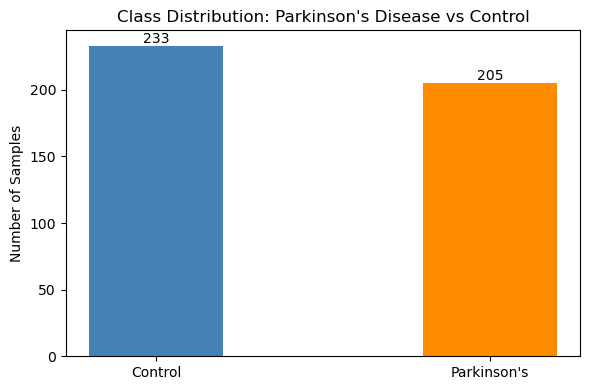

In [9]:
# Count samples per group
label_counts = t_data["label"].value_counts().rename({1: "Parkinson's", 0: "Control"})

# Bar chart
plt.figure(figsize=(6, 4))
barplot = plt.bar(label_counts.index, label_counts.values, color=["steelblue", "darkorange"], width=0.4)
plt.bar_label(barplot, labels=label_counts.values, label_type="edge")
plt.ylabel("Number of Samples")
plt.title("Class Distribution: Parkinson's Disease vs Control")
plt.tight_layout()
plt.show()

## Step 5: Compare mean expression between groups
This steps checks if IPD and Control samples have different gene expression patterns on average.

In [10]:
# Separate into PD and Control groups
pd_samples = t_data[t_data["label"] == 1].drop(columns="label")
ctrl_samples = t_data[t_data["label"] == 0].drop(columns="label")

print(f"Parkinson samples: {len(pd_samples)}")
print(f"Control samples:   {len(ctrl_samples)}")

Parkinson samples: 205
Control samples:   233


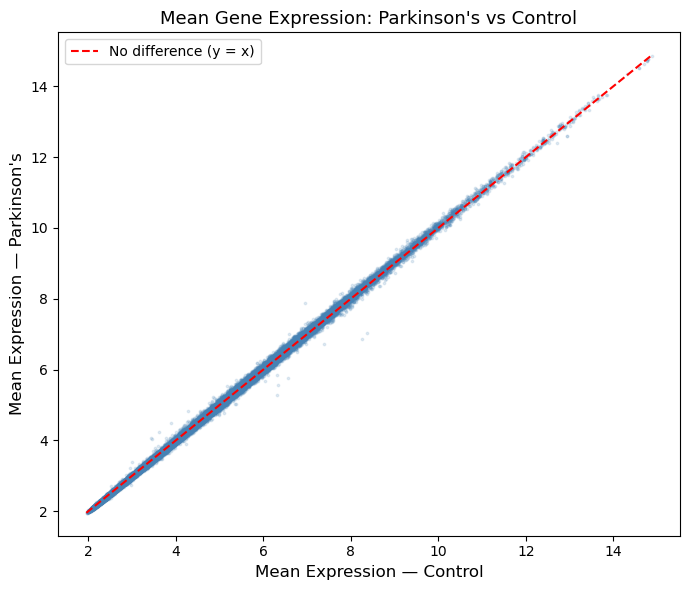

In [11]:
# Compute the mean expression of each gene in each group
mean_pd = pd_samples.mean(axis=0)    # average across all PD patients, per gene
mean_ctrl = ctrl_samples.mean(axis=0)  # average across all Control patients, per gene

# Scatter plot
plt.figure(figsize=(7, 6))
plt.scatter(mean_ctrl, mean_pd, alpha=0.15, s=3, color="steelblue")

# y=x reference line
min_val = min(mean_ctrl.min(), mean_pd.min())
max_val = max(mean_ctrl.max(), mean_pd.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label='No difference (y = x)')

plt.xlabel("Mean Expression — Control", fontsize=12)
plt.ylabel("Mean Expression — Parkinson's", fontsize=12)
plt.title("Mean Gene Expression: Parkinson's vs Control", fontsize=13)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

## Step 6: Find the most variable genes
The variance for each gene will be measured in order to find the genes that could potentially carry useful information.
- High variance = the gene behaves differently across patients = potentially informative
- Low variance = the gene is stable in everyone = not useful for classification

In [12]:
# Compute the variance of each gene across all samples
gene_variance = t_data.drop(columns='label').var(axis=0)

# Sort from highest to lowest variance
gene_variance = gene_variance.sort_values(ascending=False)

print(f"Total probes: {len(gene_variance)}")
print("\nTop 10 most variable probes:")
print(gene_variance.head(10))

Total probes: 54675

Top 10 most variable probes:
ID_REF
227671_at              14.073031
224588_at              13.479250
224590_at               8.639007
AFFX-r2-Bs-dap-3_at     8.289260
AFFX-r2-Bs-dap-M_at     7.675193
201909_at               7.613869
AFFX-DapX-3_at          7.484914
AFFX-r2-Bs-dap-5_at     7.007846
213831_at               6.696051
AFFX-DapX-M_at          6.567313
dtype: float64


Note: Several of the top variable probes have the prefix AFFX —
these are Affymetrix control probes added by the manufacturer
for technical quality control and do not represent real human genes.
These will be removed in the preprocessing step (Notebook 03).

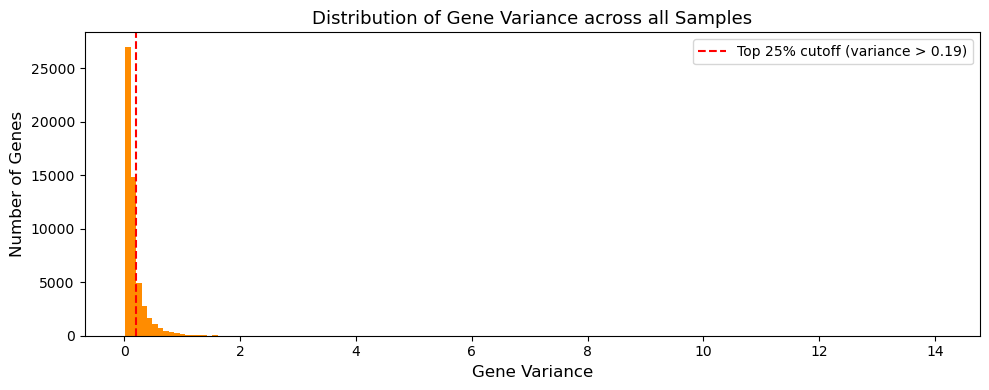

In [13]:
# Plot the distribution of gene variances

plt.figure(figsize=(10,4))
plt.hist(gene_variance.values, bins=150, color="darkorange")

# Mark the top 25% cutoff with a vertical line
cutoff = gene_variance.quantile(0.75)
plt.axvline(x=cutoff, color='red', linestyle='--', linewidth=1.5,
            label=f'Top 25% cutoff (variance > {cutoff:.2f})')

plt.xlabel("Gene Variance", fontsize=12)
plt.ylabel("Number of Genes", fontsize=12)
plt.title("Distribution of Gene Variance across all Samples", fontsize=13)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

## Step 7: Heatmap of the top 50 most variable genes

In [14]:
# Remove AFFX probes first, then take the top 50 genes
top50_genes = gene_variance[~gene_variance.index.str.startswith('AFFX')].head(50).index.tolist()

# Sort samples: IPD first and the Control
# A random subset of 30 samples in total (15 IPD, 15 Control) is going to be used so the visualization looks cleaner
pd_subset = t_data[t_data["label"] == 1].sample(15, random_state=1)
ctrl_subset = t_data[t_data["label"] == 0].sample(15, random_state=1)
subset = pd.concat([pd_subset, ctrl_subset])

# Expression matrix and row colors
heatmap_expr = subset[top50_genes]
row_colors = subset["label"].map({1: "#E07B7B", 0: "#7BA7E0"})

print(f"Heatmap: {heatmap_expr.shape[0]} samples x 50 genes")

Heatmap: 30 samples x 50 genes


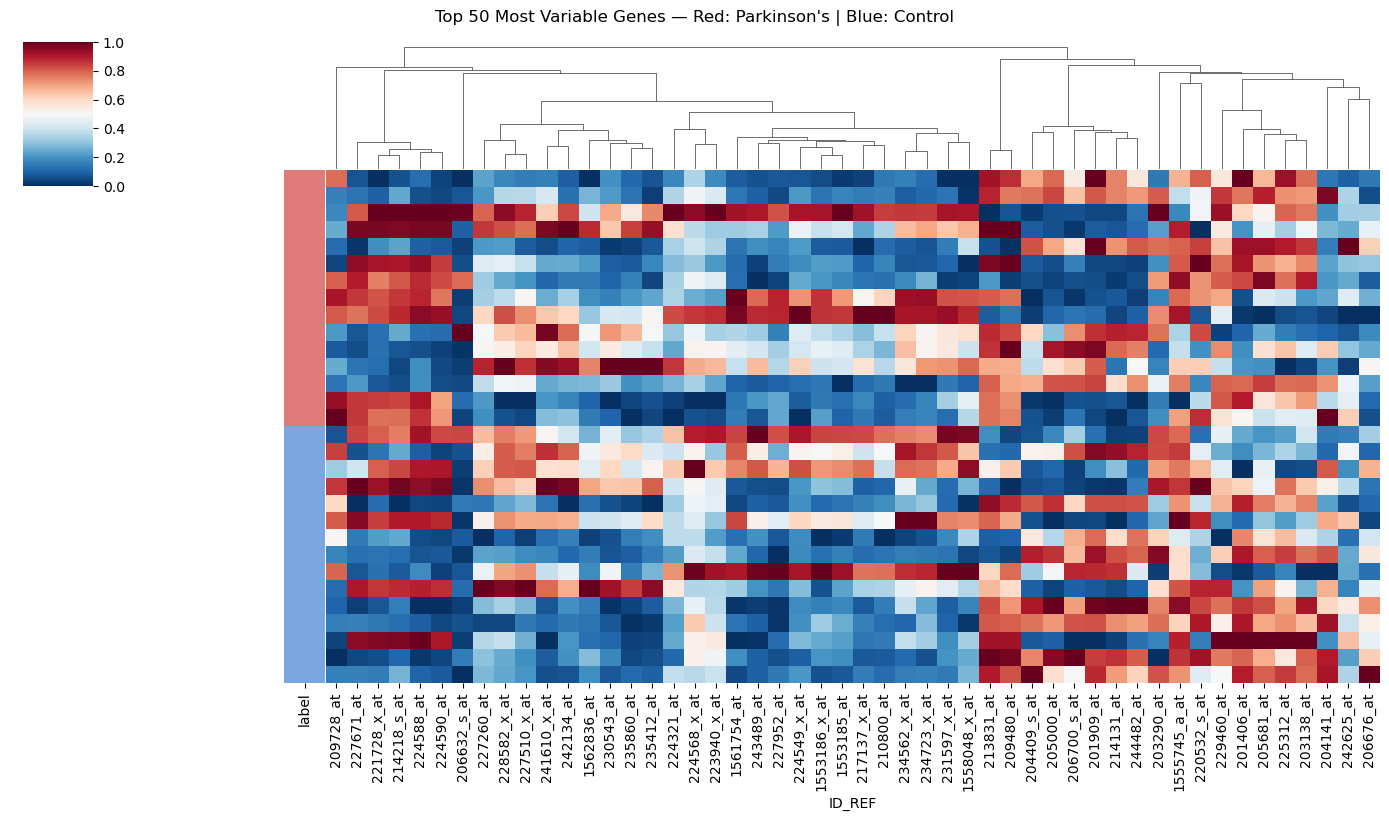

In [15]:
heatmap = sns.clustermap(
    heatmap_expr,
    row_colors=row_colors,
    row_cluster=False,
    col_cluster=True,
    cmap='RdBu_r',
    figsize=(14, 8),
    yticklabels=False,
    standard_scale=1
)

heatmap.fig.suptitle("Top 50 Most Variable Genes — Red: Parkinson's | Blue: Control",
               y=1.02, fontsize=12)
plt.show()

Note: The heatmap reveals that while most of the top 50 variable genes show 
mixed expression patterns across both groups, a subset of genes 
(visible as consistently red columns in the PD block) appear to be 
more highly expressed in IPD samples compared to controls. This 
suggests that these genes may carry discriminative signal for 
Parkinson's disease classification, which we will explore further 
in the machine learning analysis.

## Step 8: Save the labeled dataset

In [16]:
output_path = "../data/labeled_expression.csv.gz"
t_data.to_csv(output_path, compression="gzip")

print(f"Saved: {output_path}")
print(f"Shape: {t_data.shape}  ({t_data.shape[0]} samples x {t_data.shape[1]-1} probes + 1 label column)")

Saved: ../data/labeled_expression.csv.gz
Shape: (438, 54676)  (438 samples x 54675 probes + 1 label column)
